In [396]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [397]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch.csv',sep=',')
raw_data_c=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_columns.csv',sep=',')
raw_data_c.info()

C:\Users\Jose.Hurtado\AppData\Local\Temp\ipykernel_14316\3342976490.py:2: DtypeWarning: Columns (0: Unnamed: 29, 1: Unnamed: 30, 2: Unnamed: 31, 3: Unnamed: 32, 4: Unnamed: 33, 5: Unnamed: 34, 6: Unnamed: 35, 7: Unnamed: 36, 8: Unnamed: 37, 9: Unnamed: 38, 10: Unnamed: 39, 11: Unnamed: 40, 12: Unnamed: 41, 13: Unnamed: 42, 14: Unnamed: 43, 15: Unnamed: 44, 16: Unnamed: 45, 17: Unnamed: 46, 18: Unnamed: 47, 19: Unnamed: 48, 20: Unnamed: 49, 21: Unnamed: 50, 22: Unnamed: 51, 23: Unnamed: 52, 24: Unnamed: 53, 25: Unnamed: 54, 26: Unnamed: 55, 27: Unnamed: 56, 28: Unnamed: 57, 29: Unnamed: 58, 30: Unnamed: 59, 31: Unnamed: 60, 32: Unnamed: 61, 33: Unnamed: 62, 34: Unnamed: 63, 35: Unnamed: 64, 36: Unnamed: 65, 37: Unnamed: 66, 38: Unnamed: 67, 39: Unnamed: 68, 40: Unnamed: 69, 41: Unnamed: 70, 42: Unnamed: 71, 43: Unnamed: 72, 44: Unnamed: 73, 45: Unnamed: 74, 46: Unnamed: 75, 47: Unnamed: 76, 48: Unnamed: 77, 49: Unnamed: 78, 50: Unnamed: 79, 51: Unnamed: 80, 52: Unnamed: 81, 53: Unnamed:

<class 'pandas.DataFrame'>
RangeIndex: 7922 entries, 0 to 7921
Columns: 400 entries, Message to Unnamed: 399
dtypes: str(400)
memory usage: 24.2 MB


In [398]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    5396
03    2083
09     250
04     177
01      13
11       3
Name: count, dtype: int64

In [399]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])
torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133],16))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(torch_codes_0204.iloc[i,2][150:154])
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

print(torch_codes_0204[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

      i_on  i_off                  io  odometer          date  ext_ps  speed  \
0       25    300  0b1000000000000000      4402  260521190815    0.49      0   
7       25    300  0b1000000000000000      4402  260521190815    0.49      0   
10      25    300  0b1000000000000000         0  260521142204    4.98      0   
12      25    300  0b1000000000000000      4402  260521190815    0.49      0   
13      25    300  0b1000000000000000      4402  260521190815    0.49      0   
...    ...    ...                 ...       ...           ...     ...    ...   
7453    25    300                 0b0  86669592  260601022051   12.84      0   
7456    25    300   0b100000000000000  86669592  260601022816   13.97      0   
7482    25    300                 0b0  86670667  260601023528   12.85      0   
7488    25    300   0b100000000000000  86670673  260601025022   14.42      0   
7511    25    300                 0b0  86671012  260601025749   12.95      0   

       acc_fuel_c   rpm remain_fuel  gn

In [400]:
torch_codes_0204.info()

<class 'pandas.DataFrame'>
Index: 5573 entries, 0 to 7511
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      5573 non-null   str    
 1   Message      5573 non-null   str    
 2   Status       5573 non-null   str    
 3   Codes        5573 non-null   str    
 4   i_on         5573 non-null   int64  
 5   i_off        5573 non-null   int64  
 6   io           5573 non-null   str    
 7   odometer     5573 non-null   int64  
 8   date         5573 non-null   str    
 9   ext_ps       5573 non-null   float64
 10  speed        5573 non-null   int64  
 11  gnss         5573 non-null   int64  
 12  acc_fuel_c   5573 non-null   float64
 13  rpm          5573 non-null   str    
 14  cool_temp    5573 non-null   int64  
 15  remain_fuel  5573 non-null   str    
 16  engine_load  5573 non-null   int64  
dtypes: float64(2), int64(7), str(8)
memory usage: 783.7 KB


In [401]:
df=torch_codes_0204[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 5573 entries, 0 to 7511
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         5573 non-null   int64  
 1   i_off        5573 non-null   int64  
 2   io           5573 non-null   str    
 3   odometer     5573 non-null   int64  
 4   date         5573 non-null   str    
 5   ext_ps       5573 non-null   float64
 6   speed        5573 non-null   int64  
 7   acc_fuel_c   5573 non-null   float64
 8   rpm          5573 non-null   str    
 9   remain_fuel  5573 non-null   str    
 10  gnss         5573 non-null   int64  
 11  cool_temp    5573 non-null   int64  
 12  Status       5573 non-null   str    
 13  engine_load  5573 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 653.1 KB


Odometer

86671077 86336000


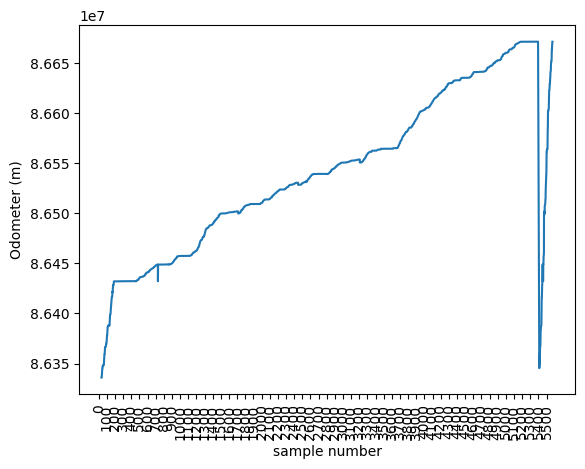

In [402]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if int(df.iloc[i,3]>80000000):
        status.append(df.iloc[i,12])
        odometer_data.append(int(df.iloc[i,3]))
        date.append(df.iloc[i,4])
        x_axis.append(i)

print(max(odometer_data),min(odometer_data))
odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

The lower peak was caused by MinsDiff=504.
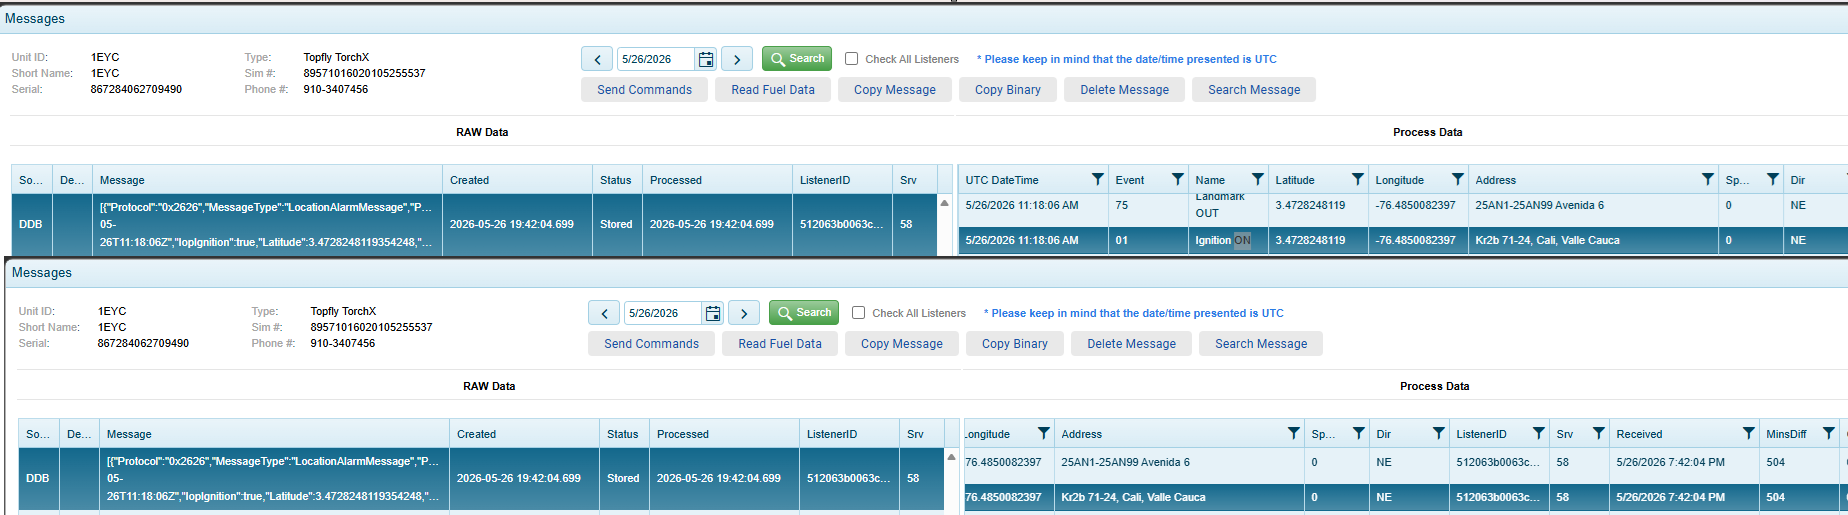

Speed

97 0


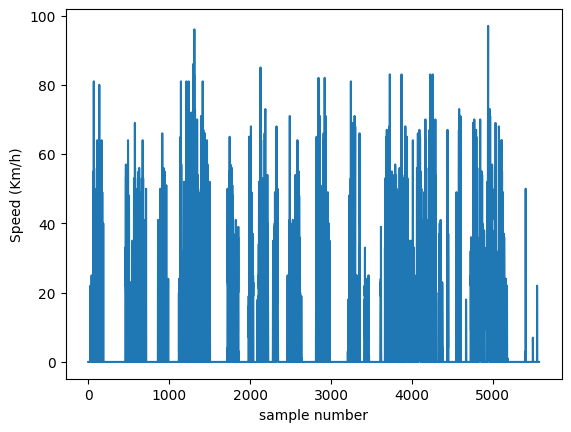

In [403]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

97 0


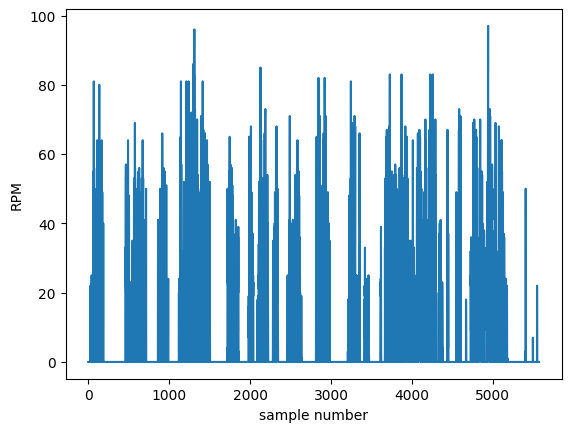

In [404]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        status.append(df.iloc[i,12])
        rpm_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=speed_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

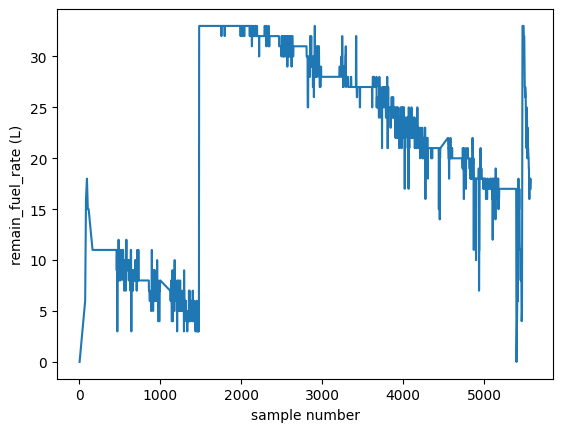

In [405]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl.csv',sep=',')

In [406]:
df.info()

<class 'pandas.DataFrame'>
Index: 5573 entries, 0 to 7511
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         5573 non-null   int64  
 1   i_off        5573 non-null   int64  
 2   io           5573 non-null   str    
 3   odometer     5573 non-null   int64  
 4   date         5573 non-null   str    
 5   ext_ps       5573 non-null   float64
 6   speed        5573 non-null   int64  
 7   acc_fuel_c   5573 non-null   float64
 8   rpm          5573 non-null   str    
 9   remain_fuel  5573 non-null   str    
 10  gnss         5573 non-null   int64  
 11  cool_temp    5573 non-null   int64  
 12  Status       5573 non-null   str    
 13  engine_load  5573 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 653.1 KB


Cooling fluid Temperature 

95 0


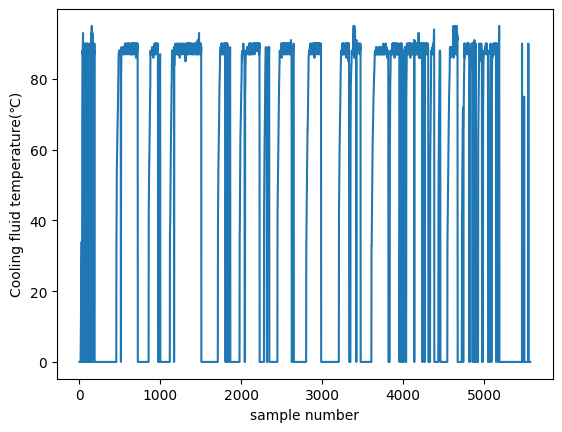

In [407]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

95 0


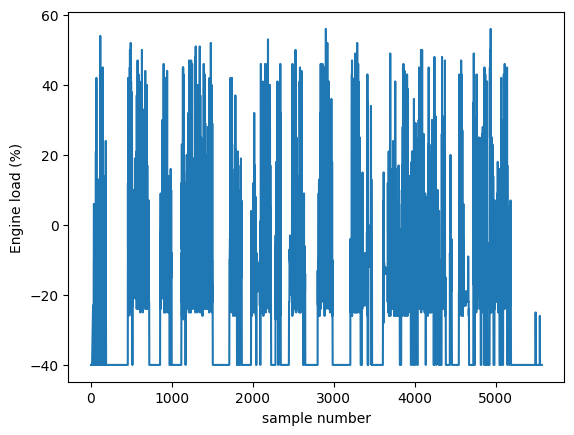

In [408]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')


Historical locations

In [409]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\historicallocations.xlsx')
hl.info()

<class 'pandas.DataFrame'>
RangeIndex: 2890 entries, 0 to 2889
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Secuencia       2890 non-null   int64  
 1   Unidad          2890 non-null   str    
 2   Eventos         2890 non-null   str    
 3   Fecha           2890 non-null   str    
 4   Pt. Referencia  693 non-null    str    
 5   Dirección       2890 non-null   str    
 6   Velocidad       2890 non-null   int64  
 7   Temperatura     0 non-null      float64
 8   Conductor       0 non-null      float64
 9   Latitud         2890 non-null   float64
 10  Longitud        2890 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 248.5 KB


In [410]:
hl['Eventos'].value_counts()

Eventos
Conduciendo             1051
Estacionado             1019
Inmóvil - Detenido       632
Saliendo de Landmark      63
Entrando a Landmark       62
Ignición Encendida        32
Ignición Apagada          31
Name: count, dtype: int64